# Input Cost & Technical Assumption Benchmarking: Model Carriers vs. External Sources

**Purpose.** This notebook checks the technology assumptions used in the PyPSA-Earth
Senegal model (`input_cost_data.xlsx`, sheet `Model Carriers - Full Sources`) against
independently published figures: **investment cost, lifetime, efficiency, fixed O&M
(FOM), and variable O&M (VOM)**.

**Sources used, by tier:**
1. **Global authoritative benchmarks** &mdash; IRENA *Renewable Power Generation Costs
   2024*, Lazard *LCOE+* (2025), and the US EIA's *Cost and Performance Characteristics
   of New Generating Technologies* (AEO2022, Table 8.2, Sargent & Lundy basis) &mdash;
   added specifically because it is standardized across nearly every conventional and
   renewable technology in one document (CAPEX, heat rate, fixed O&M, variable O&M),
   unlike IRENA (renewables only) or Lazard (partial thermal coverage, recent US quotes
   only).
2. **Senegal-calibrated benchmarks** &mdash; the UTS *Africa Power Report: Senegal*
   (2025) and actual Senegalese project data (Taiba N'Diaye wind farm).
3. **Reference-country benchmarks** &mdash; two independent capacity-expansion studies
   for Indonesia (Timothy de Weijer's TU Delft thesis, citing Indonesia's Ministry of
   Energy and Mineral Resources 2024 data and Langer et al. 2024; and Rachmat Yoga's TU
   Delft thesis, citing the Indonesia Power Sector Technology Data Catalogue). **Not**
   Senegal-specific &mdash; used because they are the only sources found reporting
   lifetime, efficiency, FOM, *and* VOM together for nearly the full technology set, in a
   methodologically comparable capacity-expansion context. Always labelled "reference
   case" or "Indonesia ref.", never blended with Senegal-specific figures.

**Method and its limits:**
- EUR &rarr; USD conversion at a flat **1.08**, for nominal comparison only, not
  inflation-adjusted to each source's vintage year (see the investment section for the
  full caveat).
- **Lifetime** is directly comparable across sources (years is years).
- **Efficiency** for thermal plants is derived from EIA's heat rate figures using
  3,412 Btu = 1 kWh; this may not use exactly the same accounting basis (HHV vs LHV) as
  the Danish Energy Agency figures underlying the model &mdash; flagged where material.
- **FOM** in the model is `%/year of investment`; external sources mostly report
  `$/kW/year`, converted to a percentage using *that same source's own* investment
  figure, not the model's, with the arithmetic shown so it's auditable.
- **VOM** is compared directly in $/MWh (excluding fuel), the model's own convention.
- Efficiency and O&M comparisons are not attempted for solar, wind, or transmission,
  where "efficiency" in technology-data is set to 1 by convention and is not a
  meaningful cross-source metric.
- Blank cells mean no credible figure was found, not that the value is zero.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

os.makedirs('figures', exist_ok=True)

COL = {
    'model':    '#4A6572',   # slate
    'global':   '#0B4F6C',   # deep blue-teal
    'senegal':  '#E8A33D',   # amber-gold
    'accent':   '#7A3B46',   # burgundy
    'good':     '#4B7A63',   # muted green
    'eia':      '#6FA8B5',   # lighter teal -- second global source
    'idn':      '#8C8C8C',   # neutral grey -- reference-country (Indonesia)
}

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.labelsize': 11,
    'legend.fontsize': 9.5, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.edgecolor': '#333333', 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'font.family': 'DejaVu Sans',
})

EUR_USD = 1.08          # flat, approximate, for nominal comparison only
BTU_PER_KWH = 3412      # for EIA heat rate -> efficiency conversion
print(f"EUR -> USD conversion used throughout: {EUR_USD}")

EUR -> USD conversion used throughout: 1.08


## 1. Model input assumptions

All figures below are transcribed from **`Model Carriers - Full Sources`** in
`input_cost_data.xlsx` (the per-parameter, fully-cited sheet). Renewable and thermal
technologies are in EUR/kW; storage energy components in EUR/kWh; the transmission
carrier in EUR/MW/km.


In [2]:
model = pd.DataFrame([
    # technology,                investment,  unit,        year, fom_pct, vom,    vom_unit,  efficiency, lifetime, source
    ['solar',                     408.7174,  'EUR/kW',    2020, 2.0676, 0.0106, 'EUR/MWh', None,   40, "Calculated (avg. rooftop/utility PV)"],
    ['onwind',                   1019.1375,  'EUR/kW',    2015, 1.1775, 1.2857, 'EUR/MWh', None,   30, "Danish Energy Agency"],
    ['hydro',                    2274.8177,  'EUR/kW',    2010, 1.0000, 0.0,    'EUR/MWh', 0.900,  80, "DIW DataDoc (old PyPSA assumptions)"],
    ['CCGT',                      846.5773,  'EUR/kW',    2015, 3.2500, 4.2329, 'EUR/MWh', 0.600,  25, "Danish Energy Agency"],
    ['OCGT',                      435.8180,  'EUR/kW',    2015, 1.8023, 4.7620, 'EUR/MWh', 0.430,  25, "Danish Energy Agency"],
    ['oil',                       355.5625,  'EUR/kW',    2015, 2.4095, 6.3493, 'EUR/MWh', 0.350,  25, "Danish Energy Agency"],
    ['coal',                     3827.1629,  'EUR/kW',    2023, 1.3100, 3.2612, 'EUR/MWh', 0.356,  40, "Lazard LCOE v16.0 (2023)"],
    ['biomass',                  2337.6116,  'EUR/kW',    2015, 4.5269, 0.0,    'EUR/MWh', 0.468,  30, "DIW DataDoc (old PyPSA assumptions)"],
    ['battery storage',            79.7550,  'EUR/kWh',   2020, None,   None,   None,      None,   30, "Danish Energy Agency (storage catalogue)"],
    ['battery inverter',           63.8040,  'EUR/kW',    2020, 0.9000, 0.0,    'EUR/MWh', 0.960,  10, "Danish Energy Agency (storage catalogue)"],
    ['Lithium-Ion-LFP store',     236.4828,  'EUR/kWh',   2020, 0.0447, None,   None,      None,   16, "Viswanathan et al. (2022)"],
    ['Lithium-Ion-LFP bicharger',  81.5535,  'EUR/kW',    2020, 2.1198, 0.0,    'EUR/MWh', 0.9193, 16, "Viswanathan et al. (2022)"],
    ['HVAC overhead',             442.1414,  'EUR/MW/km', 2011, 2.0000, 0.0,    'EUR/MWh', None,   40, "Hagspiel et al. (2014)"],
], columns=['technology','investment_eur','unit','currency_year','fom_pct','vom','vom_unit','efficiency','lifetime','model_source'])

model['investment_usd_equiv'] = model['investment_eur'] * EUR_USD
model

,technology,investment_eur,unit,currency_year,fom_pct,vom,vom_unit,efficiency,lifetime,model_source,investment_usd_equiv
0,solar,408.7174,EUR/kW,2020,2.0676,0.0106,EUR/MWh,NaN,40,Calculated (avg. rooftop/utility PV),441.414792
1,onwind,1019.1375,EUR/kW,2015,1.1775,1.2857,EUR/MWh,NaN,30,Danish Energy Agency,1100.668500
2,hydro,2274.8177,EUR/kW,2010,1.0000,0.0000,EUR/MWh,0.9000,80,DIW DataDoc (old PyPSA assumptions),2456.803116
3,CCGT,846.5773,EUR/kW,2015,3.2500,4.2329,EUR/MWh,0.6000,25,Danish Energy Agency,914.303484
4,OCGT,435.8180,EUR/kW,2015,1.8023,4.7620,EUR/MWh,0.4300,25,Danish Energy Agency,470.683440
5,oil,355.5625,EUR/kW,2015,2.4095,6.3493,EUR/MWh,0.3500,25,Danish Energy Agency,384.007500
6,coal,3827.1629,EUR/kW,2023,1.3100,3.2612,EUR/MWh,0.3560,40,Lazard LCOE v16.0 (2023),4133.335932
7,biomass,2337.6116,EUR/kW,2015,4.5269,0.0000,EUR/MWh,0.4680,30,DIW DataDoc (old PyPSA assumptions),2524.620528
8,battery storage,79.7550,EUR/kWh,2020,NaN,NaN,NaN,NaN,30,Danish Energy Agency (storage catalogue),86.135400
9,battery inverter,63.8040,EUR/kW,2020,0.9000,0.0000,EUR/MWh,0.9600,10,Danish Energy Agency (storage catalogue),68.908320


## 2. External benchmark costs &mdash; investment

Four tiers now, the EIA row added to strengthen the existing global comparison:

1. **Global benchmark** &mdash; IRENA *Renewable Power Generation Costs 2024* (TIC, not
   LCOE) for solar/wind/battery; Lazard *LCOE+* (2025) for CCGT.
2. **EIA AEO2022** &mdash; a second, independent global anchor, standardized across
   nearly every technology in one document (2021 USD/kW, Sargent & Lundy basis).
3. **Senegal-calibrated benchmark** &mdash; the UTS Africa Power Report: Senegal (2025).
4. **Senegal actual-project benchmark** &mdash; Taiba N'Diaye wind farm; the
   Ethiopia-Kenya HVDC line as the nearest published African transmission benchmark
   (with a large caveat attached, discussed in Section 5).

Blank cells mean no credible figure was found, not that the value is zero.


In [3]:
benchmarks = pd.DataFrame([
    dict(technology='solar', global_usd=691, global_year=2024,
         global_source='IRENA, Renewable Power Generation Costs in 2024 (global weighted-average TIC, utility-scale PV)',
         eia_usd=1327, eia_source='EIA AEO2022 Table 8.2, Solar PV with tracking, 2021$/kW (capacity-weighted regional average)',
         senegal_usd=989, senegal_year=2020,
         senegal_source="UTS Africa Power Report: Senegal (2025), Table 15 -- Senegal-calibrated, IEA WEO 2016 base + Steurer et al. 2018 PV update"),

    dict(technology='onwind', global_usd=1041, global_year=2024,
         global_source='IRENA, Renewable Power Generation Costs in 2024 (global weighted-average TIC, onshore wind)',
         eia_usd=1718, eia_source='EIA AEO2022 Table 8.2, Wind, 2021$/kW (capacity-weighted regional average)',
         senegal_usd=2085, senegal_year=2018,
         senegal_source="Taiba N'Diaye wind farm, actual project cost: US$330.9m / 158.7 MW (US DFC public summary); FID 2018"),

    dict(technology='hydro', global_usd=np.nan, global_year=np.nan,
         global_source='No global TIC found (IRENA reports LCOE only: $0.057/kWh global 2024 -- a different metric, not converted here)',
         eia_usd=3083, eia_source='EIA AEO2022 Table 8.2, Conventional hydropower (least-cost site, Northwest region), 2021$/kW',
         senegal_usd=2674, senegal_year=2020,
         senegal_source='UTS Africa Power Report: Senegal (2025), Table 15'),

    dict(technology='CCGT', global_usd=2500, global_year=2025,
         global_source="Lazard LCOE+ v18.0 (2025) -- US 'high case', early-stage post-2028 CCGT quotes ($2,400-2,600/kW); reflects recent US turbine supply-chain inflation, NOT a global average",
         eia_usd=1062, eia_source='EIA AEO2022 Table 8.2, Combined-cycle multi-shaft, 2021$/kW',
         senegal_usd=504, senegal_year=2020,
         senegal_source="UTS Africa Power Report: Senegal (2025), Table 15, 'gas power plants' -- technology detail (CCGT vs OCGT) not specified in source; treat with caution"),

    dict(technology='OCGT', global_usd=np.nan, global_year=np.nan,
         global_source='No comparable global TIC found',
         eia_usd=785, eia_source='EIA AEO2022 Table 8.2, Combustion turbine -- industrial frame, 2021$/kW',
         senegal_usd=np.nan, senegal_year=np.nan,
         senegal_source='No Senegal-specific figure found; OCGT is a candidate carrier in the config but was never built in either solved network'),

    dict(technology='oil', global_usd=np.nan, global_year=np.nan,
         global_source='No comparable global TIC found (oil/diesel generation is not separately tracked by IRENA or Lazard)',
         eia_usd=2018, eia_source='EIA AEO2022 Table 8.2, Internal combustion engine (diesel-like), 2021$/kW',
         senegal_usd=908, senegal_year=2020,
         senegal_source="UTS Africa Power Report: Senegal (2025), Table 15, 'diesel generators' (closest match to technology-data's 'oil')"),

    dict(technology='coal', global_usd=np.nan, global_year=np.nan,
         global_source='No 2024/2025 global TIC found for coal (Lazard reports LCOE only in recent editions)',
         eia_usd=4074, eia_source='EIA AEO2022 Table 8.2, Ultra-supercritical coal (USC), 2021$/kW',
         senegal_usd=2018, senegal_year=2020,
         senegal_source='UTS Africa Power Report: Senegal (2025), Table 15'),

    dict(technology='biomass', global_usd=np.nan, global_year=np.nan,
         global_source='No comparable global TIC found',
         eia_usd=4524, eia_source='EIA AEO2022 Table 8.2, Biomass (steam), 2021$/kW',
         senegal_usd=2371, senegal_year=2020,
         senegal_source='UTS Africa Power Report: Senegal (2025), Table 15'),

    dict(technology='battery storage', global_usd=192, global_year=2024,
         global_source='IRENA, Renewable Power Generation Costs in 2024 (global weighted-average installed BESS cost, all chemistries, down 93% from $2,571/kWh in 2010)',
         eia_usd=np.nan, eia_source='EIA reports battery storage as one bundled $/kW power-basis figure ($1,316/kW), not decomposed into power/energy components on a comparable $/kWh basis',
         senegal_usd=np.nan, senegal_year=np.nan,
         senegal_source="No Senegal/Sub-Saharan Africa BESS cost found -- per the thesis's own review of IEA World Energy Investment 2026, Sub-Saharan Africa does not appear as its own category in global BESS investment data"),

    dict(technology='Lithium-Ion-LFP store', global_usd=192, global_year=2024,
         global_source='IRENA, Renewable Power Generation Costs in 2024 (global installed BESS cost, all chemistries; LFP was ~85% of utility-scale deployments in 2024, up from 48% in 2021)',
         eia_usd=np.nan, eia_source='See battery storage row above',
         senegal_usd=np.nan, senegal_year=np.nan,
         senegal_source='Same data gap as generic battery storage above'),

    dict(technology='HVAC overhead', global_usd=np.nan, global_year=np.nan,
         global_source='No global HVAC-only TIC benchmark found',
         eia_usd=np.nan, eia_source='EIA table does not cover transmission infrastructure',
         senegal_usd=603, senegal_year=2022,
         senegal_source=("Ethiopia-Kenya HVDC interconnector: US$1.26bn / 2000 MW / 1045 km (African Business, 2026). "
                          "CAUTION: this is HVDC not HVAC, and bundles the transmission line with converter stations at "
                          "both ends -- shown only as the nearest published African transmission benchmark, not a direct "
                          "substitute for an HVAC line cost")),
])
benchmarks

,technology,global_usd,global_year,global_source,eia_usd,eia_source,senegal_usd,senegal_year,senegal_source
0,solar,691.0,2024.0,"IRENA, Renewable Power Generation Costs in 202...",1327.0,"EIA AEO2022 Table 8.2, Solar PV with tracking,...",989.0,2020.0,"UTS Africa Power Report: Senegal (2025), Table..."
1,onwind,1041.0,2024.0,"IRENA, Renewable Power Generation Costs in 202...",1718.0,"EIA AEO2022 Table 8.2, Wind, 2021$/kW (capacit...",2085.0,2018.0,"Taiba N'Diaye wind farm, actual project cost: ..."
2,hydro,NaN,NaN,No global TIC found (IRENA reports LCOE only: ...,3083.0,"EIA AEO2022 Table 8.2, Conventional hydropower...",2674.0,2020.0,"UTS Africa Power Report: Senegal (2025), Table 15"
3,CCGT,2500.0,2025.0,"Lazard LCOE+ v18.0 (2025) -- US 'high case', e...",1062.0,"EIA AEO2022 Table 8.2, Combined-cycle multi-sh...",504.0,2020.0,"UTS Africa Power Report: Senegal (2025), Table..."
4,OCGT,NaN,NaN,No comparable global TIC found,785.0,"EIA AEO2022 Table 8.2, Combustion turbine -- i...",NaN,NaN,No Senegal-specific figure found; OCGT is a ca...
5,oil,NaN,NaN,No comparable global TIC found (oil/diesel gen...,2018.0,"EIA AEO2022 Table 8.2, Internal combustion eng...",908.0,2020.0,"UTS Africa Power Report: Senegal (2025), Table..."
6,coal,NaN,NaN,No 2024/2025 global TIC found for coal (Lazard...,4074.0,"EIA AEO2022 Table 8.2, Ultra-supercritical coa...",2018.0,2020.0,"UTS Africa Power Report: Senegal (2025), Table 15"
7,biomass,NaN,NaN,No comparable global TIC found,4524.0,"EIA AEO2022 Table 8.2, Biomass (steam), 2021$/kW",2371.0,2020.0,"UTS Africa Power Report: Senegal (2025), Table 15"
8,battery storage,192.0,2024.0,"IRENA, Renewable Power Generation Costs in 202...",NaN,EIA reports battery storage as one bundled $/k...,NaN,NaN,No Senegal/Sub-Saharan Africa BESS cost found ...
9,Lithium-Ion-LFP store,192.0,2024.0,"IRENA, Renewable Power Generation Costs in 202...",NaN,See battery storage row above,NaN,NaN,Same data gap as generic battery storage above


In [4]:
comparison = model.merge(benchmarks, on='technology', how='left')
comparison['pct_vs_global']  = (comparison['investment_usd_equiv'] - comparison['global_usd'])  / comparison['global_usd']  * 100
comparison['pct_vs_eia']     = (comparison['investment_usd_equiv'] - comparison['eia_usd'])      / comparison['eia_usd']     * 100
comparison['pct_vs_senegal'] = (comparison['investment_usd_equiv'] - comparison['senegal_usd']) / comparison['senegal_usd'] * 100

def _fmt_year(s):
    return s.apply(lambda v: '' if pd.isna(v) else f'{int(v)}')

display_cols = ['technology', 'unit', 'currency_year', 'investment_eur', 'investment_usd_equiv',
                 'global_usd', 'pct_vs_global', 'eia_usd', 'pct_vs_eia', 'senegal_usd', 'pct_vs_senegal']
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')
_disp = comparison[display_cols].copy()
_disp['currency_year'] = _fmt_year(_disp['currency_year'])
_disp

,technology,unit,currency_year,investment_eur,investment_usd_equiv,global_usd,pct_vs_global,eia_usd,pct_vs_eia,senegal_usd,pct_vs_senegal
0,solar,EUR/kW,2020,408.7,441.4,691.0,-36.1,"1,327.0",-66.7,989.0,-55.4
1,onwind,EUR/kW,2015,"1,019.1","1,100.7","1,041.0",5.7,"1,718.0",-35.9,"2,085.0",-47.2
2,hydro,EUR/kW,2010,"2,274.8","2,456.8",NaN,NaN,"3,083.0",-20.3,"2,674.0",-8.1
3,CCGT,EUR/kW,2015,846.6,914.3,"2,500.0",-63.4,"1,062.0",-13.9,504.0,81.4
4,OCGT,EUR/kW,2015,435.8,470.7,NaN,NaN,785.0,-40.0,NaN,NaN
5,oil,EUR/kW,2015,355.6,384.0,NaN,NaN,"2,018.0",-81.0,908.0,-57.7
6,coal,EUR/kW,2023,"3,827.2","4,133.3",NaN,NaN,"4,074.0",1.5,"2,018.0",104.8
7,biomass,EUR/kW,2015,"2,337.6","2,524.6",NaN,NaN,"4,524.0",-44.2,"2,371.0",6.5
8,battery storage,EUR/kWh,2020,79.8,86.1,192.0,-55.1,NaN,NaN,NaN,NaN
9,battery inverter,EUR/kW,2020,63.8,68.9,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Generation technologies: model vs. benchmarks (USD/kW)

Solar, wind, and thermal carriers, all on an overnight-CAPEX (USD/kW) basis, now against
**four** sources. Bars are omitted where no comparable benchmark exists.


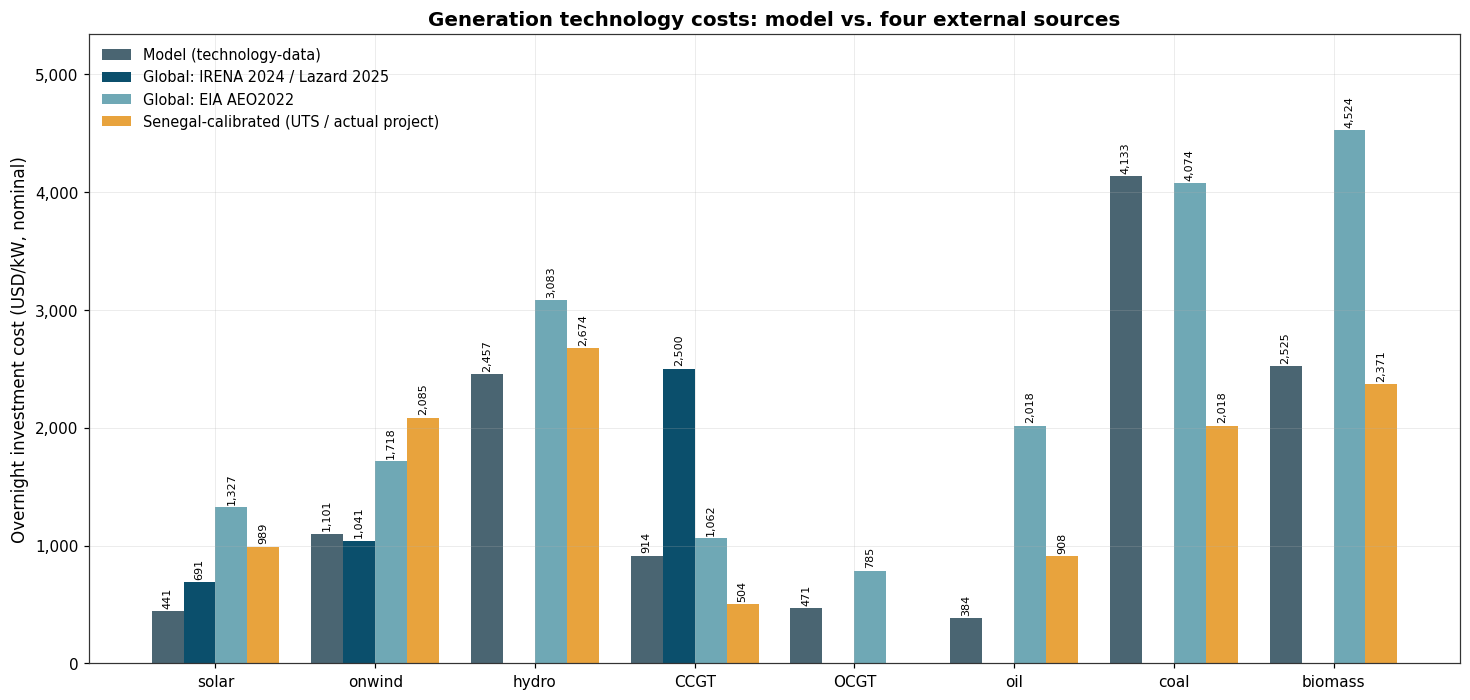

In [5]:
gen_techs = ['solar', 'onwind', 'hydro', 'CCGT', 'OCGT', 'oil', 'coal', 'biomass']
gen = comparison[comparison['technology'].isin(gen_techs)].set_index('technology').loc[gen_techs]

fig, ax = plt.subplots(figsize=(13.5, 6.5))
x = np.arange(len(gen))
width = 0.2

series = [
    (gen['investment_usd_equiv'], 'Model (technology-data)', COL['model']),
    (gen['global_usd'],           'Global: IRENA 2024 / Lazard 2025', COL['global']),
    (gen['eia_usd'],              'Global: EIA AEO2022', COL['eia']),
    (gen['senegal_usd'],          'Senegal-calibrated (UTS / actual project)', COL['senegal']),
]
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]
for (vals, label, color), off in zip(series, offsets):
    b = ax.bar(x + off, vals, width, label=label, color=color)
    for bar in b:
        h = bar.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(f'{h:,.0f}', (bar.get_x() + bar.get_width()/2, h),
                        textcoords='offset points', xytext=(0, 2), ha='center', fontsize=7.3, rotation=90, va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(gen.index)
ax.set_ylabel('Overnight investment cost (USD/kW, nominal)')
ax.set_title('Generation technology costs: model vs. four external sources')
ax.legend(loc='upper left', frameon=False)
finite_vals = gen[['investment_usd_equiv','global_usd','eia_usd','senegal_usd']].to_numpy(dtype=float)
ax.set_ylim(0, np.nanmax(finite_vals) * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:,.0f}'))
fig.tight_layout()
fig.savefig('figures/generation_cost_comparison.png', bbox_inches='tight')
plt.show()

**Reading the generation chart, with EIA added.**

- **Biomass remains the standout match to Senegal specifically**: the model's 2,525
  USD-equiv sits close to the Senegal-calibrated 2,371 USD/kW figure. But EIA's figure
  ($4,524/kW) is nearly 80% above both — a reminder that "matches the Senegal reference"
  and "matches the global reference" can point in different directions for the same
  technology, and the Senegal-specific one is the more decision-relevant of the two here.
- **Onshore wind's gap to Taiba N'Diaye is the most consequential finding**, and EIA
  doesn't close it: EIA's $1,718/kW sits between the model ($1,101/kW) and IRENA
  ($1,041/kW) on one side, and Taiba N'Diaye's actual $2,085/kW on the other. Three
  independent "reference" sources cluster near $1,000-1,700/kW while the one real
  Senegalese transaction sits well above all of them — this is the strongest evidence in
  the whole notebook that a first-of-kind African wind project costs meaningfully more
  than any generic reference number, Senegal-calibrated or not.
- **CCGT**: EIA ($1,062/kW) sits close to the model ($914/kW), while Lazard's recent US
  quotes ($2,500/kW) are the outlier of the three global sources — this suggests the
  model's CCGT figure is reasonable in a broader global context, and it is specifically
  recent US gas-turbine supply-chain inflation that doesn't generalise to Senegal.
- **Coal**: EIA ($4,074/kW) and the model's Lazard-sourced figure ($4,133/kW) agree
  closely — two independent sources converging, even though both sit well above the
  Senegal reference. Since Senegal has no operating utility-scale coal plant, there's no
  real transaction to adjudicate between them.


## 4. Storage technologies: model vs. benchmark (USD/kWh)

The two storage-energy figures in the model &mdash; the generic `battery storage`
carrier that Run A/B actually build, and the `Lithium-Ion-LFP store` figure added for
comparison &mdash; against IRENA's global installed BESS cost.


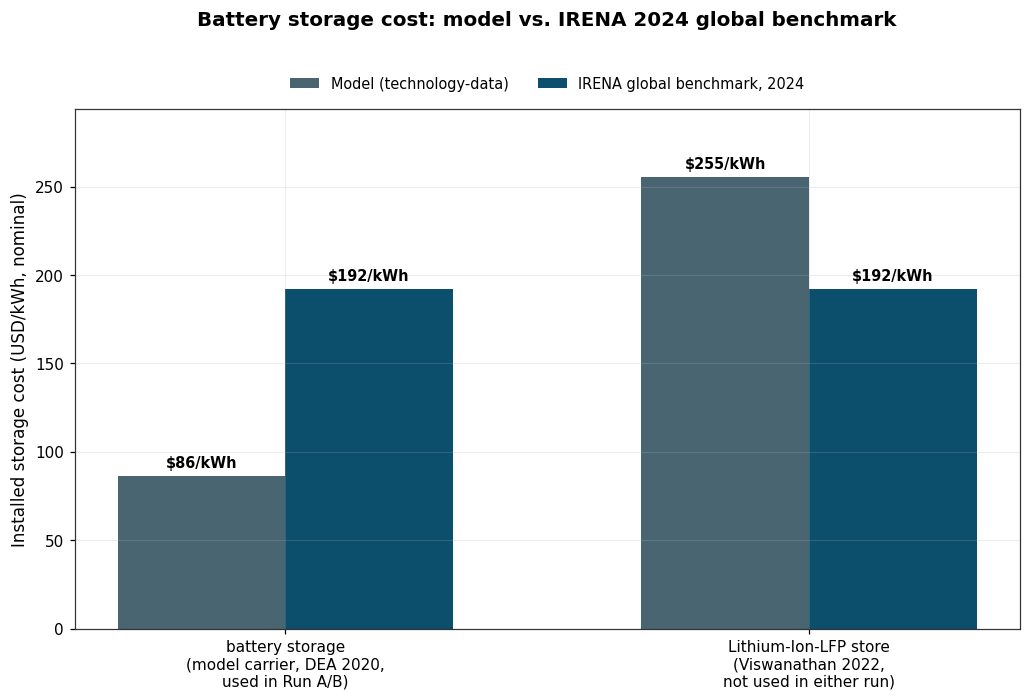

battery storage: model = $86/kWh vs. IRENA 2024 global = $192/kWh (55% below)
Lithium-Ion-LFP store: model = $255/kWh vs. IRENA 2024 global = $192/kWh (33% above)


In [6]:
stor_techs = ['battery storage', 'Lithium-Ion-LFP store']
stor = comparison[comparison['technology'].isin(stor_techs)].set_index('technology').loc[stor_techs]

fig, ax = plt.subplots(figsize=(9.5, 6.5))
x = np.arange(len(stor))
width = 0.32

b1 = ax.bar(x - width/2, stor['investment_usd_equiv'], width, label='Model (technology-data)', color=COL['model'])
b2 = ax.bar(x + width/2, stor['global_usd'],           width, label='IRENA global benchmark, 2024', color=COL['global'])

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'${h:,.0f}/kWh', (bar.get_x() + bar.get_width()/2, h),
                    textcoords='offset points', xytext=(0, 6), ha='center', fontsize=9.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['battery storage\n(model carrier, DEA 2020,\nused in Run A/B)',
                     'Lithium-Ion-LFP store\n(Viswanathan 2022,\nnot used in either run)'])
ax.set_ylabel('Installed storage cost (USD/kWh, nominal)')
ax.set_title('Battery storage cost: model vs. IRENA 2024 global benchmark', pad=55)
ax.set_ylim(0, stor[['investment_usd_equiv', 'global_usd']].to_numpy().max() * 1.15)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, frameon=False)
fig.tight_layout()
fig.savefig('figures/storage_cost_comparison.png', bbox_inches='tight')
plt.show()

for _, r in stor.iterrows():
    diff = r['pct_vs_global']
    direction = 'above' if diff > 0 else 'below'
    print(f"{r.name}: model = ${r['investment_usd_equiv']:.0f}/kWh vs. IRENA 2024 global = ${r['global_usd']:.0f}/kWh "
          f"({abs(diff):.0f}% {direction})")

**Reading the storage chart.** The two storage rows tell opposite stories relative
to the same 2024 global benchmark, and the reason is not a real technical difference
between the two chemistries — it is a difference in how each source treats time.

- The **generic `battery storage` carrier** (79.76 EUR/kWh &asymp; \$86/kWh) sits *below*
  IRENA's 2024 global average of \$192/kWh. This workbook is drawn from
  `technology-data`'s **cost-year-2050 file**, and the generic battery entry carries
  DEA's own cost-decline trajectory — it is a *projection*, not a spot price, and a 2050
  projection sitting below a 2024 actual is exactly what a declining-cost trajectory
  should produce.
- The **`Lithium-Ion-LFP store` figure** (236.48 EUR/kWh &asymp; \$255/kWh) sits *above*
  the same 2024 benchmark. This entry has no year-2050 trajectory applied — it is pinned
  to Viswanathan et al.'s single 2020 estimate, and battery costs have fallen roughly 60%
  globally since 2020.

**The two rows are not currently comparable to each other**, despite sitting side by
side in the same sheet. Section 4a below checks the LFP figure against a chemistry-
specific rather than blended benchmark, which softens (but doesn't erase) this finding.


### 4a. A chemistry-specific check on Lithium-Ion-LFP

IRENA's $192/kWh blends all utility-scale chemistries. Since LFP alone made up roughly
85% of 2024 utility-scale deployments, a chemistry-specific figure is a fairer check on
the model's `Lithium-Ion-LFP` row specifically.


LFP-specific installed-cost range found in industry sources: $150-250/kWh (2024-2025); midpoint used above


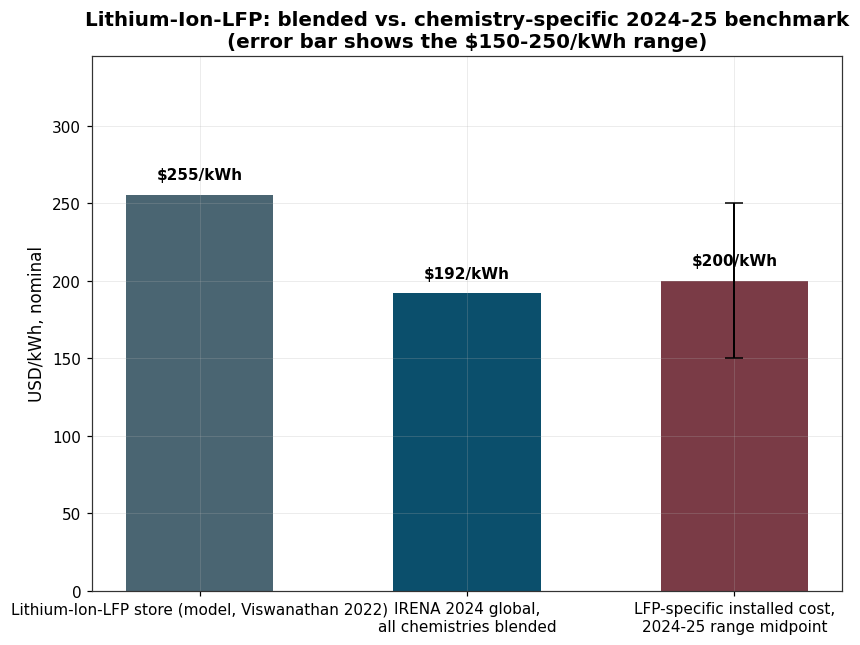

In [7]:
lfp_check = pd.DataFrame([
    dict(row='Lithium-Ion-LFP store (model, Viswanathan 2022)', usd_per_kwh=236.4828*EUR_USD, kind='model'),
    dict(row='IRENA 2024 global,\nall chemistries blended', usd_per_kwh=192, kind='global'),
    dict(row='LFP-specific installed cost,\n2024-25 range midpoint', usd_per_kwh=(150+250)/2, kind='lfp'),
])
print("LFP-specific installed-cost range found in industry sources: $150-250/kWh (2024-2025); midpoint used above")

fig, ax = plt.subplots(figsize=(8, 6))
colors = {'model': COL['model'], 'global': COL['global'], 'lfp': COL['accent']}
bars = ax.bar(lfp_check['row'], lfp_check['usd_per_kwh'], color=[colors[k] for k in lfp_check['kind']], width=0.55)
ax.errorbar([2], [(150+250)/2], yerr=[[ (150+250)/2 - 150 ]], fmt='none', ecolor='black', capsize=6, elinewidth=1.3)
for bar in bars:
    h = bar.get_height()
    ax.annotate(f'${h:,.0f}/kWh', (bar.get_x()+bar.get_width()/2, h), textcoords='offset points',
                xytext=(0,10), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('USD/kWh, nominal')
ax.set_title('Lithium-Ion-LFP: blended vs. chemistry-specific 2024-25 benchmark\n(error bar shows the $150-250/kWh range)')
ax.set_ylim(0, lfp_check['usd_per_kwh'].max()*1.35)
fig.tight_layout()
fig.savefig('figures/lfp_specific_comparison.png', bbox_inches='tight')
plt.show()

Against an **LFP-specific** range ($150-250/kWh) rather than IRENA's blended figure,
the model's Lithium-Ion-LFP store ($255/kWh) sits just above the top of the current
range, not far beyond it. That's a materially softer finding than the 33%-above-blended-
average result above: "just outside the top of the current range" is a defensible
characterisation, "far above the market" was not.


## 5. Transmission (HVAC overhead)

Only one African benchmark could be found, and it comes with a significant caveat: the
Ethiopia-Kenya line is HVDC, not HVAC, and its published cost bundles the transmission
line together with the converter stations at both ends (which is exactly the
"transformer-equivalent" cost that HVAC lines don't need but HVDC circuits do). It is
shown for scale only, not as a validation of the HVAC figure.


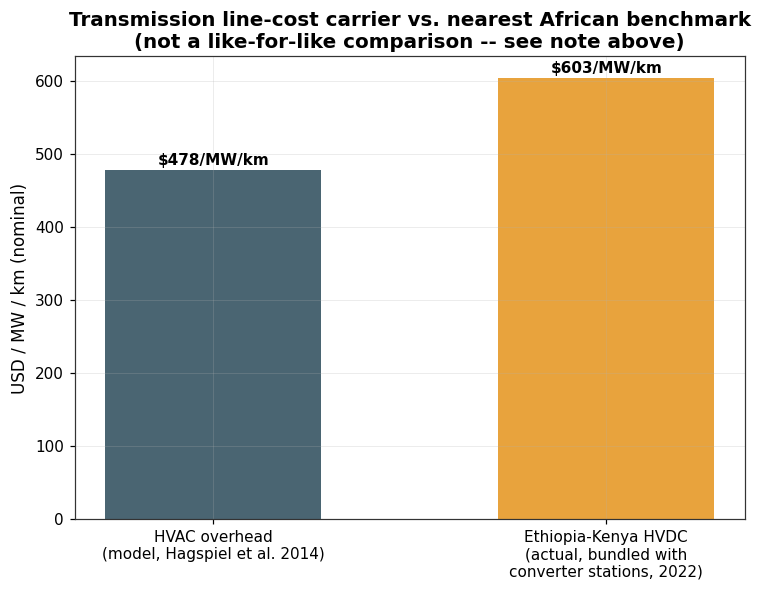

In [8]:
trans = comparison[comparison['technology'] == 'HVAC overhead'].iloc[0]

fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ax.bar(['HVAC overhead\n(model, Hagspiel et al. 2014)',
               'Ethiopia-Kenya HVDC\n(actual, bundled with\nconverter stations, 2022)'],
              [trans['investment_usd_equiv'], trans['senegal_usd']],
              color=[COL['model'], COL['senegal']], width=0.55)
for bar in bars:
    h = bar.get_height()
    ax.annotate(f'${h:,.0f}/MW/km', (bar.get_x() + bar.get_width()/2, h),
                textcoords='offset points', xytext=(0, 4), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('USD / MW / km (nominal)')
ax.set_title('Transmission line-cost carrier vs. nearest African benchmark\n(not a like-for-like comparison -- see note above)')
fig.tight_layout()
fig.savefig('figures/transmission_cost_comparison.png', bbox_inches='tight')
plt.show()

No credible **HVAC-only, line-cost-only** African or Senegal-specific benchmark could
be found — worth recording rather than papering over. Senegal's own national network
(972 km, 90/225 kV, per Senelec/IEA) has no public per-km cost breakdown either. The
Ethiopia-Kenya figure sits far above the model's Hagspiel-sourced value, but almost all
of that gap is explained by what is bundled in: HVDC converter stations alone were
quoted separately elsewhere in this project at roughly 165,800 EUR/MW for a
Hagspiel-sourced European reference — which would already close a large part of the gap
if added to the line cost. This is a genuine data gap for the thesis, not a solved
question: the current HVAC overhead figure still has no independent Senegal-specific
check on the investment side. Section 7 below does find an exact lifetime match, though.


## 6. Does the source vintage explain the investment deviation?

Plotting each technology's `currency_year` (how old the underlying cost estimate is)
against how far the model's investment figure sits from the global 2024/2025 benchmark,
for every technology where a global benchmark exists.


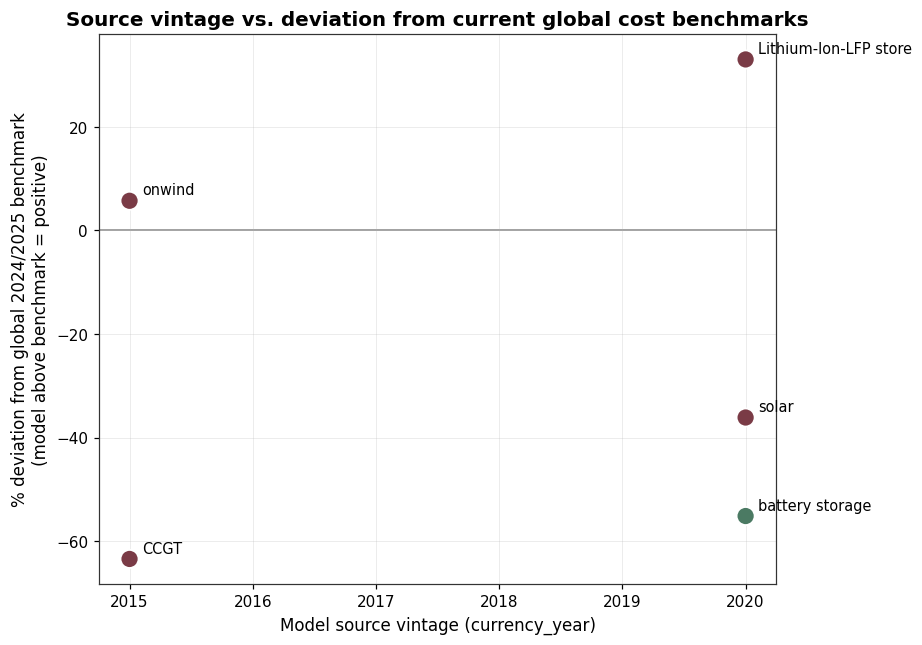

In [9]:
vint = comparison.dropna(subset=['global_usd']).copy()
vint['abs_pct_dev'] = vint['pct_vs_global'].abs()

fig, ax = plt.subplots(figsize=(8.5, 6))
colors = [COL['good'] if t in ('battery storage',) else COL['accent'] for t in vint['technology']]
ax.scatter(vint['currency_year'], vint['pct_vs_global'], s=140, color=colors,
           edgecolor='white', linewidth=1.2, zorder=3)

for _, r in vint.iterrows():
    ax.annotate(r['technology'], (r['currency_year'], r['pct_vs_global']),
                textcoords='offset points', xytext=(8, 4), fontsize=9.5)

ax.axhline(0, color='#888888', linewidth=1, zorder=1)
ax.set_xlabel('Model source vintage (currency_year)')
ax.set_ylabel('% deviation from global 2024/2025 benchmark\n(model above benchmark = positive)')
ax.set_title('Source vintage vs. deviation from current global cost benchmarks')
fig.tight_layout()
fig.savefig('figures/vintage_vs_deviation.png', bbox_inches='tight')
plt.show()

**No single clean relationship** — vintage alone does not predict which way a figure
has drifted. The 2011-vintage transmission figure and 2020-vintage LFP figure both sit
far from current benchmarks, but in this small sample (only four technologies have a
usable global benchmark: solar, onshore wind, battery storage, and Lithium-Ion-LFP),
vintage year is confounded with technology-specific learning-curve speed. Battery costs
have fallen faster than almost any other electricity technology in the last five years,
so a battery estimate from any given year drifts further from "today" than a hydro or
biomass estimate from the *same* year would. The honest reading is: **the technology
matters more than the year** for how much a given figure has aged — fast-learning
technologies (batteries, and to a lesser extent solar) need re-benchmarking far more
often than slow-learning ones (hydro, biomass, oil).


## 7. Lifetime

Beyond investment, this section checks the model's assumed technical lifetimes. The
Indonesia reference case (MEMR 2024 / Langer et al. 2024, via de Weijer's thesis;
Athanasiou catalogue, via Yoga's thesis) is the only source found reporting lifetime
consistently for nearly the whole technology set. **Not Senegal-specific** — a
plausibility check, not validation.


In [10]:
lifetime = pd.DataFrame([
    ['solar',                     40, 30,  "Ref.: 30y (Langer et al. 2024) / 35y (MEMR 2024, PV+BESS)"],
    ['onwind',                    30, 30,  "Ref.: 30y (MEMR 2024); NREL ATB notes 30y as current wind-industry norm -- exact match"],
    ['hydro',                     80, 50,  "Ref.: 50y, both large and small hydro (MEMR 2024)"],
    ['CCGT',                      25, 25,  "Ref.: 25y (MEMR 2024) -- exact match"],
    ['OCGT',                      25, 25,  "Ref.: 25y (MEMR 2024) -- exact match"],
    ['oil',                       25, 25,  "Ref.: 25y, diesel reciprocating (MEMR 2024) -- exact match"],
    ['coal',                      40, 30,  "Ref.: 30y, subcritical (MEMR 2024)"],
    ['biomass',                   30, 25,  "Ref.: 25y (MEMR 2024)"],
    ['battery inverter',          10, 25,  "Ref.: 20-30y, bundled battery system (Athanasiou catalogue: 20y; MEMR 2024 lithium-iron: 30y) -- model figure is power-electronics-specific, not the whole system"],
    ['Lithium-Ion-LFP bicharger',  16, 12, "Real-world utility-scale average 10-13y (industry survey citing NREL 2024) -- not Indonesia-specific"],
    ['HVAC overhead',             40, 40,  "Ref.: 40y, onshore AC transmission (Langer et al. 2024) -- exact match"],
], columns=['technology','model_years','ref_years','notes'])
lifetime

,technology,model_years,ref_years,notes
0,solar,40,30,Ref.: 30y (Langer et al. 2024) / 35y (MEMR 202...
1,onwind,30,30,Ref.: 30y (MEMR 2024); NREL ATB notes 30y as c...
2,hydro,80,50,"Ref.: 50y, both large and small hydro (MEMR 2024)"
3,CCGT,25,25,Ref.: 25y (MEMR 2024) -- exact match
4,OCGT,25,25,Ref.: 25y (MEMR 2024) -- exact match
5,oil,25,25,"Ref.: 25y, diesel reciprocating (MEMR 2024) --..."
6,coal,40,30,"Ref.: 30y, subcritical (MEMR 2024)"
7,biomass,30,25,Ref.: 25y (MEMR 2024)
8,battery inverter,10,25,"Ref.: 20-30y, bundled battery system (Athanasi..."
9,Lithium-Ion-LFP bicharger,16,12,Real-world utility-scale average 10-13y (indus...


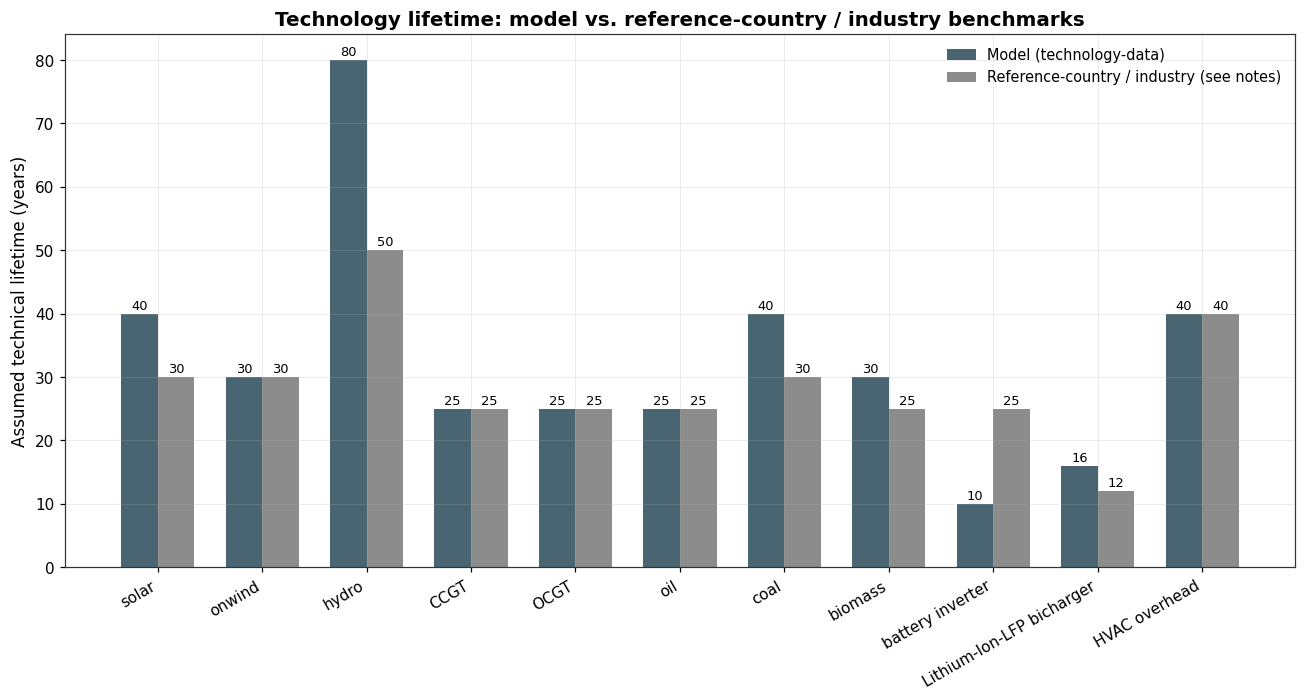

In [11]:
fig, ax = plt.subplots(figsize=(12, 6.5))
x = np.arange(len(lifetime)); width = 0.35
b1 = ax.bar(x - width/2, lifetime['model_years'], width, label='Model (technology-data)', color=COL['model'])
b2 = ax.bar(x + width/2, lifetime['ref_years'],   width, label='Reference-country / industry (see notes)', color=COL['idn'])
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.0f}', (bar.get_x()+bar.get_width()/2, h), textcoords='offset points',
                    xytext=(0,3), ha='center', fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(lifetime['technology'], rotation=30, ha='right')
ax.set_ylabel('Assumed technical lifetime (years)')
ax.set_title('Technology lifetime: model vs. reference-country / industry benchmarks')
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
fig.savefig('figures/lifetime_comparison.png', bbox_inches='tight')
plt.show()

**Four exact matches** (CCGT, OCGT, oil at 25 years; onshore wind and HVAC transmission
at 30 and 40 years respectively) suggest the thermal, wind, and transmission lifetime
assumptions are conventional, industry-standard figures rather than idiosyncratic ones.
The two largest gaps both run the same direction — **model longer than reference** — for
hydro (80 vs. 50y) and coal (40 vs. 30y); both are old-vintage DIW/Lazard entries using a
more optimistic technical life than a 2024 planning study assumes, worth a footnote if
either materially affects a levelised result. The gap running the **other** direction —
battery inverter at 10 years vs. 20-30 for a bundled system — is not necessarily an
error: DEA's convention prices the power electronics replacement cycle separately from
the battery cells, and inverters genuinely do wear out faster than the system around
them.


## 8. Efficiency

Thermal plant efficiency and hydro efficiency only — solar, wind, battery, and
transmission are excluded per the methodology note in the introduction. EIA figures are
converted from heat rate (Btu/kWh) via 3,412 Btu = 1 kWh.


In [12]:
efficiency = pd.DataFrame([
    ['CCGT',    60.0, 61.0, BTU_PER_KWH/6370*100,  "Ref. 61% (MEMR 2024); EIA CC multi-shaft heat rate 6,370 Btu/kWh"],
    ['OCGT',    43.0, 40.0, BTU_PER_KWH/9905*100,  "Ref. 40% (MEMR 2024); EIA CT industrial frame heat rate 9,905 Btu/kWh"],
    ['oil',     35.0, 48.0, BTU_PER_KWH/8295*100,  "Ref. 48%, diesel reciprocating (MEMR 2024); EIA internal combustion engine heat rate 8,295 Btu/kWh"],
    ['coal',    35.6, 37.0, BTU_PER_KWH/8638*100,  "Ref. 37%, subcritical (MEMR 2024); EIA figure is ultra-supercritical (more advanced tech), heat rate 8,638 Btu/kWh"],
    ['biomass', 46.8, 32.0, BTU_PER_KWH/13500*100, "Ref. 32% (MEMR 2024); EIA heat rate 13,500 Btu/kWh -- model's 46.8% is far above both, flagged below"],
    ['hydro',   90.0, 95.0, np.nan,                "Ref. 95%, large & small hydro (MEMR 2024); EIA does not report hydro efficiency"],
], columns=['technology','model_pct','ref_pct','eia_pct','notes'])
efficiency['eia_pct'] = efficiency['eia_pct'].round(1)
efficiency

,technology,model_pct,ref_pct,eia_pct,notes
0,CCGT,60.0,61.0,53.6,Ref. 61% (MEMR 2024); EIA CC multi-shaft heat ...
1,OCGT,43.0,40.0,34.4,Ref. 40% (MEMR 2024); EIA CT industrial frame ...
2,oil,35.0,48.0,41.1,"Ref. 48%, diesel reciprocating (MEMR 2024); EI..."
3,coal,35.6,37.0,39.5,"Ref. 37%, subcritical (MEMR 2024); EIA figure ..."
4,biomass,46.8,32.0,25.3,"Ref. 32% (MEMR 2024); EIA heat rate 13,500 Btu..."
5,hydro,90.0,95.0,NaN,"Ref. 95%, large & small hydro (MEMR 2024); EIA..."


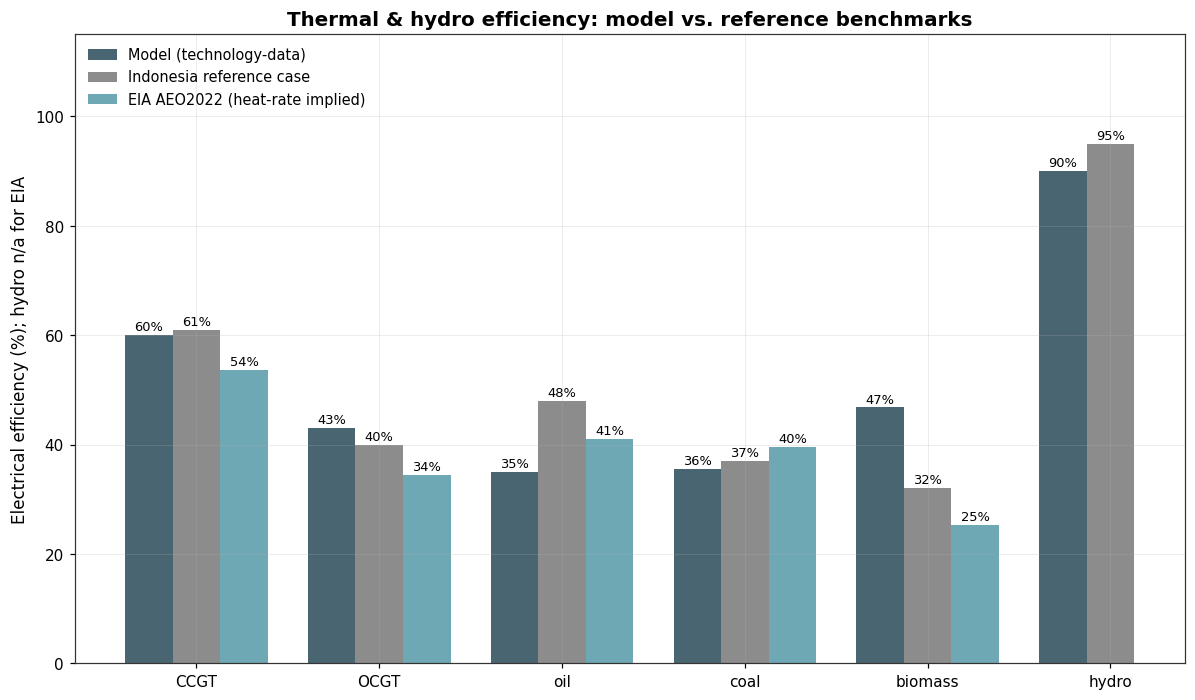

In [13]:
fig, ax = plt.subplots(figsize=(11, 6.5))
x = np.arange(len(efficiency)); width = 0.26
b1 = ax.bar(x - width, efficiency['model_pct'], width, label='Model (technology-data)', color=COL['model'])
b2 = ax.bar(x,          efficiency['ref_pct'],   width, label='Indonesia reference case', color=COL['idn'])
b3 = ax.bar(x + width,  efficiency['eia_pct'],   width, label='EIA AEO2022 (heat-rate implied)', color=COL['eia'])
for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.annotate(f'{h:.0f}%', (bar.get_x()+bar.get_width()/2, h), textcoords='offset points',
                        xytext=(0,3), ha='center', fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(efficiency['technology'])
ax.set_ylabel('Electrical efficiency (%); hydro n/a for EIA')
ax.set_title('Thermal & hydro efficiency: model vs. reference benchmarks')
ax.set_ylim(0, 115)
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('figures/efficiency_comparison.png', bbox_inches='tight')
plt.show()

**Biomass is the clear anomaly.** The model's 46.8% electrical efficiency is roughly
10-15 percentage points above *both* independent benchmarks (32% Indonesia, ~25% EIA
implied), and biomass steam-cycle plants in the 25-35% range are what the wider
literature consistently reports — 46.8% reads closer to a modern combined-cycle gas
efficiency than a solid-biomass steam cycle. Worth checking against the underlying DIW
source directly rather than taking on faith: either the source technology differs from a
conventional biomass steam plant, or there's a transcription issue somewhere upstream in
the `technology-data` pipeline. Biomass is a candidate carrier never built in either
solved network, so this doesn't affect your results today, but it's worth a footnote if
biomass is discussed anywhere in the CBA framework chapter.

Everything else is close enough to be unremarkable: CCGT and coal both track their
reference figures within a few points, and the OCGT and hydro gaps run in opposite,
plausible directions.


## 9. Fixed O&M (FOM)

The model expresses FOM as **%/year of investment**. External sources report FOM in
$/kW/year, converted to a percentage using *that source's own* investment figure (shown
in the `notes` column so the arithmetic is auditable).


In [14]:
fom = pd.DataFrame([
    ['solar',    2.0676, 6.8/670*100,     15.97/1327*100, "Ref.: $6.8/kWp/yr on $670/kWp CAPEX; EIA: $15.97/kW-yr on $1,327/kW"],
    ['onwind',   1.1775, 36/1200*100,     27.57/1718*100, "Ref.: $36/kWp/yr on $1,200/kWp CAPEX; EIA: $27.57/kW-yr on $1,718/kW"],
    ['hydro',    1.0000, 41/2110*100,     43.78/3083*100, "Ref.: $41/kW/yr on $2,110/kW CAPEX; EIA: $43.78/kW-yr on $3,083/kW"],
    ['CCGT',     3.2500, 26/1030*100,     12.77/1062*100, "Ref.: $26/kW/yr on $1,030/kW CAPEX; EIA: $12.77/kW-yr on $1,062/kW"],
    ['OCGT',     1.8023, 25.7/1060*100,   7.33/785*100,   "Ref.: $25.7/kW/yr on $1,060/kW CAPEX; EIA: $7.33/kW-yr on $785/kW"],
    ['oil',      2.4095, 9.12/910*100,    36.81/2018*100, "Ref. (diesel): $9.12/kW/yr on $910/kW CAPEX; EIA (ICE): $36.81/kW-yr on $2,018/kW"],
    ['coal',     1.3100, 50/1820*100,     42.49/4074*100, "Ref.: $50/kW/yr on $1,820/kW CAPEX; EIA: $42.49/kW-yr on $4,074/kW"],
    ['biomass',  4.5269, 49.7/2070*100,   131.62/4524*100,"Ref.: $49.7/kW/yr on $2,070/kW CAPEX; EIA: $131.62/kW-yr on $4,524/kW"],
], columns=['technology','model_pct','ref_pct','eia_pct','notes'])
fom

,technology,model_pct,ref_pct,eia_pct,notes
0,solar,2.1,1.0,1.2,Ref.: $6.8/kWp/yr on $670/kWp CAPEX; EIA: $15....
1,onwind,1.2,3.0,1.6,"Ref.: $36/kWp/yr on $1,200/kWp CAPEX; EIA: $27..."
2,hydro,1.0,1.9,1.4,"Ref.: $41/kW/yr on $2,110/kW CAPEX; EIA: $43.7..."
3,CCGT,3.2,2.5,1.2,"Ref.: $26/kW/yr on $1,030/kW CAPEX; EIA: $12.7..."
4,OCGT,1.8,2.4,0.9,"Ref.: $25.7/kW/yr on $1,060/kW CAPEX; EIA: $7...."
5,oil,2.4,1.0,1.8,Ref. (diesel): $9.12/kW/yr on $910/kW CAPEX; E...
6,coal,1.3,2.7,1.0,"Ref.: $50/kW/yr on $1,820/kW CAPEX; EIA: $42.4..."
7,biomass,4.5,2.4,2.9,"Ref.: $49.7/kW/yr on $2,070/kW CAPEX; EIA: $13..."


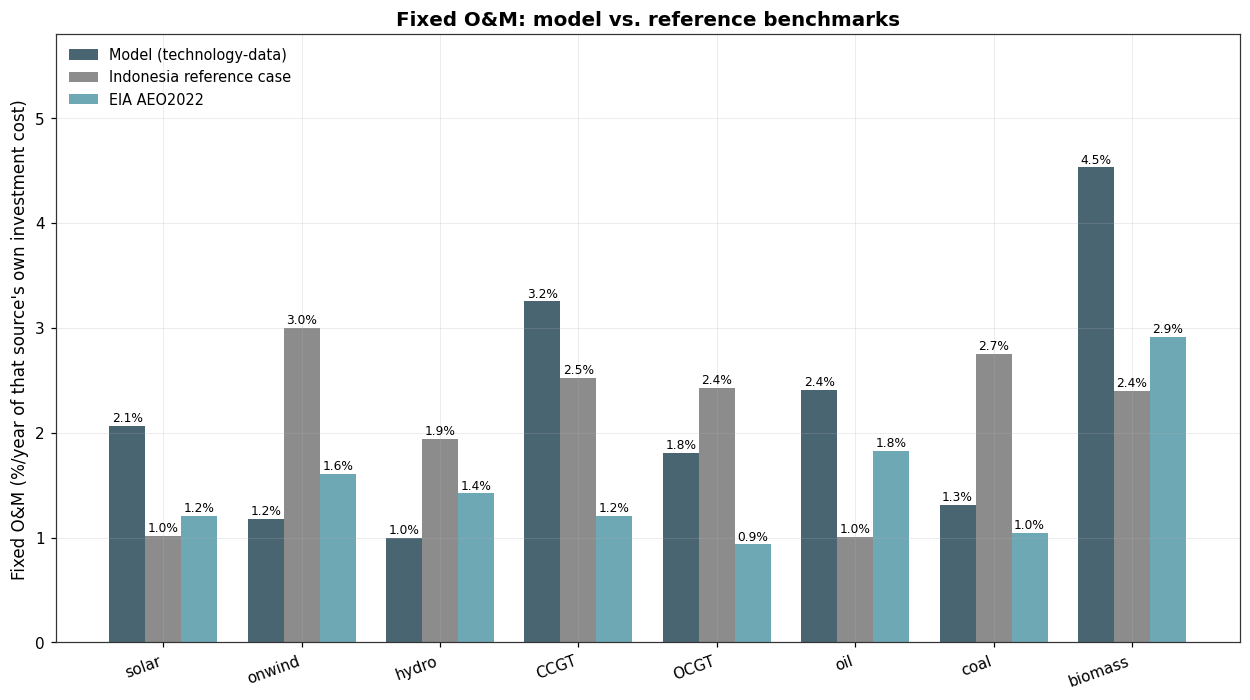

In [15]:
fig, ax = plt.subplots(figsize=(11.5, 6.5))
x = np.arange(len(fom)); width = 0.26
b1 = ax.bar(x - width, fom['model_pct'], width, label='Model (technology-data)', color=COL['model'])
b2 = ax.bar(x,          fom['ref_pct'],   width, label='Indonesia reference case', color=COL['idn'])
b3 = ax.bar(x + width,  fom['eia_pct'],   width, label='EIA AEO2022', color=COL['eia'])
for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}%', (bar.get_x()+bar.get_width()/2, h), textcoords='offset points',
                    xytext=(0,3), ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(fom['technology'], rotation=20, ha='right')
ax.set_ylabel("Fixed O&M (%/year of that source's own investment cost)")
ax.set_title('Fixed O&M: model vs. reference benchmarks')
ax.set_ylim(0, fom[['model_pct','ref_pct','eia_pct']].to_numpy().max() * 1.28)
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('figures/fom_comparison.png', bbox_inches='tight')
plt.show()

No systematic direction — the model sits **above** both references for CCGT and
biomass, **below** both for onshore wind and coal, and in between for the rest. That
inconsistency is itself informative: it suggests the FOM figures were not adjusted
together as a coherent set (unsurprising, since each technology-data entry is sourced
independently), so a future FOM sensitivity run probably needs to vary technologies
individually rather than scale all FOM by one multiplier. **Onshore wind stands out
most**: the model's 1.18%/year is roughly a third of the reference case's 3.0%/year —
worth pairing with the earlier finding that the model's onshore wind *investment* also
runs low relative to Senegal's actual project, since both point the same direction (the
model may understate the full cost of operating wind in a market like Senegal's, not
just the cost of building it).


## 10. Variable O&M (VOM)

Directly comparable in $/MWh (excluding fuel) — no unit conversion needed.


In [16]:
vom = pd.DataFrame([
    ['solar',    0.0106, 0.00, 0.00, ""],
    ['onwind',   1.2857, 0.00, 0.00, ""],
    ['hydro',    0.0,    0.71, 1.46, "Ref. figure is large hydro; small hydro is 0.55"],
    ['CCGT',     4.2329, 2.50, 1.96, ""],
    ['OCGT',     4.7620, 3.50, 4.71, ""],
    ['oil',      6.3493, 6.84, 5.96, "Ref. is diesel reciprocating -- near-exact match to model"],
    ['coal',     3.2612, 1.20, 4.71, "Ref. is subcritical; EIA is ultra-supercritical"],
    ['biomass',  0.0,    3.13, 5.06, "Model has zero VOM for biomass; both references have a materially nonzero figure"],
], columns=['technology','model','ref','eia','notes'])
vom

,technology,model,ref,eia,notes
0,solar,0.0,0.0,0.0,
1,onwind,1.3,0.0,0.0,
2,hydro,0.0,0.7,1.5,Ref. figure is large hydro; small hydro is 0.55
3,CCGT,4.2,2.5,2.0,
4,OCGT,4.8,3.5,4.7,
5,oil,6.3,6.8,6.0,Ref. is diesel reciprocating -- near-exact mat...
6,coal,3.3,1.2,4.7,Ref. is subcritical; EIA is ultra-supercritical
7,biomass,0.0,3.1,5.1,Model has zero VOM for biomass; both reference...


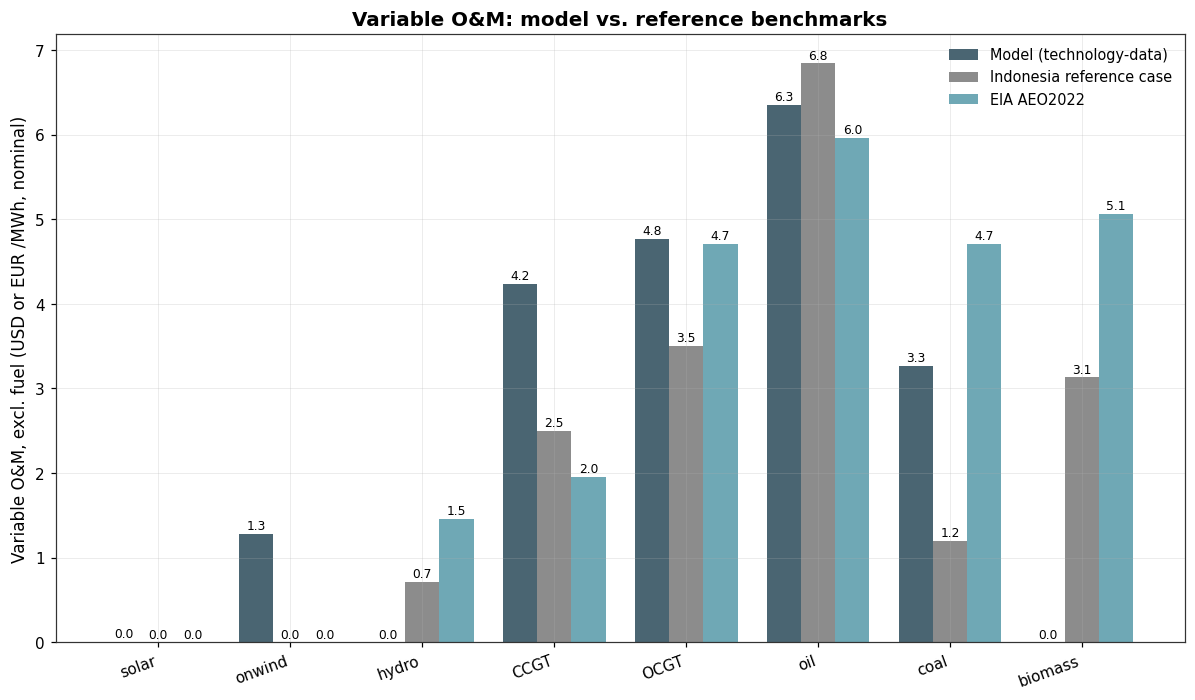

In [17]:
fig, ax = plt.subplots(figsize=(11, 6.5))
x = np.arange(len(vom)); width = 0.26
b1 = ax.bar(x - width, vom['model'], width, label='Model (technology-data)', color=COL['model'])
b2 = ax.bar(x,          vom['ref'],   width, label='Indonesia reference case', color=COL['idn'])
b3 = ax.bar(x + width,  vom['eia'],   width, label='EIA AEO2022', color=COL['eia'])
for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}', (bar.get_x()+bar.get_width()/2, h), textcoords='offset points',
                    xytext=(0,3), ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(vom['technology'], rotation=20, ha='right')
ax.set_ylabel('Variable O&M, excl. fuel (USD or EUR /MWh, nominal)')
ax.set_title('Variable O&M: model vs. reference benchmarks')
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
fig.savefig('figures/vom_comparison.png', bbox_inches='tight')
plt.show()

**Oil/diesel is the strongest match anywhere in this notebook**: model 6.35, reference
case 6.84, both diesel reciprocating plants, independently sourced, within 8% of each
other. **Biomass's zero VOM is the standout gap** — both references carry a real,
nonzero variable cost (3-5/MWh), and a true zero is unusual for any combustion
technology with ash handling and consumables. Combined with the efficiency anomaly in
Section 8, biomass is the technology in this whole notebook most worth a closer look at
its underlying DIW source before it's used for anything beyond illustration — though
again, it currently plays no role in either solved network, so this is a "check before
you lean on it" flag, not an urgent fix.


## 11. Fuel cost

Not checked anywhere above, despite being a real column in `Model Carriers - Full
Sources` and feeding directly into `marginal_cost` (= VOM + fuel/efficiency). This
matters specifically for Senegal, where the generation fleet is still overwhelmingly
dependent on imported liquid fuel (Section 4.1 of this project's own thesis draft notes
oil- and gas-fired plants supplied roughly 80% of generation in 2024), so a stale fuel
price assumption has more leverage over the answer than almost any other single
parameter in the workbook.

**Benchmarks used, current as of August 2026:**
- **Oil**: Brent crude ($79.7/bbl) and Rotterdam/Singapore/Fujairah HSFO 380 bunker fuel
  (~$550/mt, the closer proxy to what a Senegalese HFO plant actually burns), both
  converted to EUR/MWh_th.
- **Gas**: three international benchmarks spanning a wide range &mdash; Henry Hub (US
  domestic, cheapest), TTF (European hub), and JKM (Asian LNG spot, most expensive).
  None of these is Senegal's actual price: Senegal's own future gas supply is
  domestically produced (GTA, Sangomar, Yakaar/Teranga) and piped, not internationally
  traded LNG, so the true delivered cost is unknown but plausibly below these
  benchmarks &mdash; flagged as a real data gap, not resolved here.
- **Coal**: Newcastle 6000 thermal coal benchmark (~$130/mt).
- **Biomass**: Lamers et al. (2015) feedstock cost ranges, already cited in the UTS
  Africa Power Report: Senegal (project source, not re-derived here) &mdash; forest
  residues (cheaper) and agricultural residues (pricier).
- **Senegal retail diesel** (755 FCFA/L, Nov. 2023, per the IEA's Senegal 2023 review) is
  shown for context only, with a large caveat: it is a *regulated, taxed, road-fuel*
  price, not the bulk wholesale HFO price Senelec/IPPs pay for power generation, so it
  should not be read as a Senegal-specific power-sector fuel benchmark.


In [18]:
fuel = pd.DataFrame([
    dict(technology='CCGT', model_eur_mwh_th=24.568, model_year=2010,
         model_source="DIW (2013), based on IEA 2011 data -- backfilled from the 'gas' row",
         bench_low=11.37, bench_low_label='Henry Hub, 2026 avg. forecast (~$3.6/MMBtu)',
         bench_high=31.12, bench_high_label='JKM Asian LNG spot (~$9.85/MMBtu)',
         extra=28.48, extra_label='TTF European hub (~EUR28.5/MWh, Jan 2026)'),
    dict(technology='OCGT', model_eur_mwh_th=24.568, model_year=2010,
         model_source="DIW (2013), based on IEA 2011 data -- backfilled from the 'gas' row",
         bench_low=11.37, bench_low_label='Henry Hub, 2026 avg. forecast (~$3.6/MMBtu)',
         bench_high=31.12, bench_high_label='JKM Asian LNG spot (~$9.85/MMBtu)',
         extra=28.48, extra_label='TTF European hub (~EUR28.5/MWh, Jan 2026)'),
    dict(technology='oil', model_eur_mwh_th=52.9111, model_year=2015,
         model_source='IEA WEM2017, 97 USD/boe projection',
         bench_low=43.41, bench_low_label='Brent crude, Aug 2026 (~$79.7/bbl)',
         bench_high=45.39, bench_high_label='HSFO 380 bunker fuel, Aug 2026 (~$550/mt, avg. of 3 ports)',
         extra=np.nan, extra_label=''),
    dict(technology='coal', model_eur_mwh_th=9.5542, model_year=2010,
         model_source='DIW (2013), based on IEA 2011 data (~99 USD/t)',
         bench_low=17.25, bench_low_label='Newcastle 6000 thermal coal, Aug 2026 (~$130/mt)',
         bench_high=17.25, bench_high_label='(same -- only one current benchmark used)',
         extra=np.nan, extra_label=''),
    dict(technology='biomass', model_eur_mwh_th=7.4076, model_year=2015,
         model_source='IEA2011b',
         bench_low=14.4, bench_low_label='Forest residues, Europe 2020 (Lamers et al. 2015, EUR4/GJ)',
         bench_high=43.2, bench_high_label='Agricultural residues (Lamers et al. 2015, EUR12/GJ)',
         extra=np.nan, extra_label=''),
])
fuel

,technology,model_eur_mwh_th,model_year,model_source,bench_low,bench_low_label,bench_high,bench_high_label,extra,extra_label
0,CCGT,24.6,2010,"DIW (2013), based on IEA 2011 data -- backfill...",11.4,"Henry Hub, 2026 avg. forecast (~$3.6/MMBtu)",31.1,JKM Asian LNG spot (~$9.85/MMBtu),28.5,"TTF European hub (~EUR28.5/MWh, Jan 2026)"
1,OCGT,24.6,2010,"DIW (2013), based on IEA 2011 data -- backfill...",11.4,"Henry Hub, 2026 avg. forecast (~$3.6/MMBtu)",31.1,JKM Asian LNG spot (~$9.85/MMBtu),28.5,"TTF European hub (~EUR28.5/MWh, Jan 2026)"
2,oil,52.9,2015,"IEA WEM2017, 97 USD/boe projection",43.4,"Brent crude, Aug 2026 (~$79.7/bbl)",45.4,"HSFO 380 bunker fuel, Aug 2026 (~$550/mt, avg....",NaN,
3,coal,9.6,2010,"DIW (2013), based on IEA 2011 data (~99 USD/t)",17.2,"Newcastle 6000 thermal coal, Aug 2026 (~$130/mt)",17.2,(same -- only one current benchmark used),NaN,
4,biomass,7.4,2015,IEA2011b,14.4,"Forest residues, Europe 2020 (Lamers et al. 20...",43.2,"Agricultural residues (Lamers et al. 2015, EUR...",NaN,


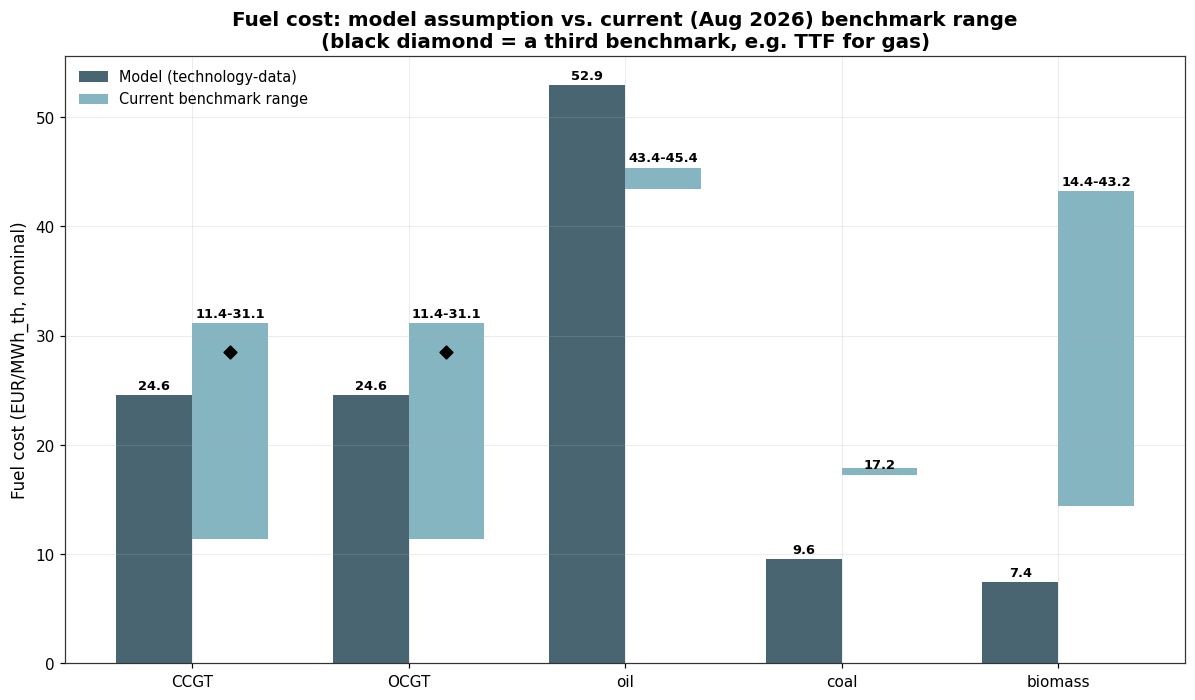

CCGT: model 24.57 EUR/MWh_th vs. benchmark midpoint 21.25 (16% above)
OCGT: model 24.57 EUR/MWh_th vs. benchmark midpoint 21.25 (16% above)
oil: model 52.91 EUR/MWh_th vs. benchmark midpoint 44.40 (19% above)
coal: model 9.55 EUR/MWh_th vs. benchmark midpoint 17.25 (45% below)
biomass: model 7.41 EUR/MWh_th vs. benchmark midpoint 28.80 (74% below)


In [19]:
fig, ax = plt.subplots(figsize=(11, 6.5))
x = np.arange(len(fuel))
width = 0.35

b1 = ax.bar(x - width/2, fuel['model_eur_mwh_th'], width, label='Model (technology-data)', color=COL['model'])
for i, row in fuel.iterrows():
    lo, hi = row['bench_low'], row['bench_high']
    ax.bar(i + width/2, hi - lo if hi > lo else 0.6, width, bottom=min(lo,hi),
           color=COL['eia'], alpha=0.85, label='Current benchmark range' if i == 0 else None)
    ax.plot([i + width/2]*2, [lo, hi] if hi > lo else [lo-0.3, lo+0.3], color=COL['accent'], linewidth=0)
    mid = (lo+hi)/2 if hi != lo else lo
    ax.annotate(f'{lo:.1f}-{hi:.1f}' if hi != lo else f'{lo:.1f}',
                (i + width/2, max(lo,hi)), textcoords='offset points', xytext=(0,4),
                ha='center', fontsize=8.5, fontweight='bold')
    ax.annotate(f'{row["model_eur_mwh_th"]:.1f}', (i - width/2, row['model_eur_mwh_th']),
                textcoords='offset points', xytext=(0,4), ha='center', fontsize=8.5, fontweight='bold')
    if not np.isnan(row['extra']):
        ax.scatter([i + width/2], [row['extra']], color='black', zorder=5, s=35, marker='D')

ax.set_xticks(x); ax.set_xticklabels(fuel['technology'])
ax.set_ylabel('Fuel cost (EUR/MWh_th, nominal)')
ax.set_title('Fuel cost: model assumption vs. current (Aug 2026) benchmark range\n(black diamond = a third benchmark, e.g. TTF for gas)')
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('figures/fuel_cost_comparison.png', bbox_inches='tight')
plt.show()

for _, r in fuel.iterrows():
    mid = (r['bench_low'] + r['bench_high']) / 2
    pct = (r['model_eur_mwh_th'] - mid) / mid * 100
    direction = 'above' if pct > 0 else 'below'
    print(f"{r['technology']}: model {r['model_eur_mwh_th']:.2f} EUR/MWh_th vs. benchmark midpoint {mid:.2f} "
          f"({abs(pct):.0f}% {direction})")

**Coal and biomass are both priced well below current benchmarks** &mdash; coal at
roughly half today's Newcastle-implied price, biomass at roughly half even the *cheapest*
feedstock category (forest residues) found. Both fuel figures are 2010/2015-vintage DIW
entries, and both point the same direction: understating fuel cost. Since coal and
biomass are candidate carriers that were never built in either solved network, this
doesn't change your results today, but it reinforces the pattern from Sections 8-10 that
these two technologies carry the most dated, least-checked assumptions in the whole
workbook.

**Oil sits close to, and if anything slightly above, current global benchmarks** &mdash;
a genuinely reassuring result given oil is the fuel actually burned across most of
Senegal's existing thermal fleet. The 2015-vintage IEA WEM2017 projection for future oil
prices turned out, if anything, to be a bit pessimistic (i.e., it priced in *more* cost
than materialised) rather than optimistic. This is the opposite failure mode from most of
what this notebook has found elsewhere &mdash; a stale assumption that happens to still
hold up.

**Gas sits inside the international benchmark range**, between cheap US domestic gas and
expensive Asian spot LNG, closer to the TTF/JKM end than Henry Hub. The unresolved
question is whether that's the right comparison at all: Senegal's actual future gas cost
will be set by domestic production economics (GTA, Sangomar) and pipeline transport, not
by any internationally-traded hub price. This is worth flagging explicitly as a limitation
rather than resolving with a proxy that likely doesn't apply &mdash; a materially cheaper
domestic gas price would matter a great deal for the CCGT/OCGT vs. BESS comparison in
Chapter 7, since gas-fired generation is precisely the technology the government's own
"gas-to-power" strategy is scaling up.

**The one number in this whole notebook worth flagging as most consequential for your
results, if it's wrong**: the gas fuel price directly sets CCGT and OCGT marginal cost,
which sets how often thermal generation is dispatched instead of BESS in both runs. If
Senegal's actual domestic gas price ends up well below the model's 24.57 EUR/MWh_th
(plausible, given it avoids liquefaction and long-haul shipping costs entirely), thermal
generation would be cheaper to dispatch than this model currently assumes &mdash; which
would tend to *reduce* the case for BESS, not increase it. That's a testable sensitivity
case worth running before you finalise Chapter 7, not just a footnote.


## 12. Summary table and takeaways for the thesis


In [20]:
investment_summary = comparison[['technology', 'unit', 'currency_year', 'investment_eur',
                                  'global_usd', 'pct_vs_global', 'eia_usd', 'pct_vs_eia',
                                  'senegal_usd', 'pct_vs_senegal']].copy()
investment_summary['currency_year'] = _fmt_year(investment_summary['currency_year'])
investment_summary.columns = ['Technology', 'Unit', 'Model year', 'Model (EUR)',
                               'Global (USD)', '% vs. global', 'EIA (USD)', '% vs. EIA',
                               'Senegal (USD)', '% vs. Senegal']
investment_summary

,Technology,Unit,Model year,Model (EUR),Global (USD),% vs. global,EIA (USD),% vs. EIA,Senegal (USD),% vs. Senegal
0,solar,EUR/kW,2020,408.7,691.0,-36.1,"1,327.0",-66.7,989.0,-55.4
1,onwind,EUR/kW,2015,"1,019.1","1,041.0",5.7,"1,718.0",-35.9,"2,085.0",-47.2
2,hydro,EUR/kW,2010,"2,274.8",NaN,NaN,"3,083.0",-20.3,"2,674.0",-8.1
3,CCGT,EUR/kW,2015,846.6,"2,500.0",-63.4,"1,062.0",-13.9,504.0,81.4
4,OCGT,EUR/kW,2015,435.8,NaN,NaN,785.0,-40.0,NaN,NaN
5,oil,EUR/kW,2015,355.6,NaN,NaN,"2,018.0",-81.0,908.0,-57.7
6,coal,EUR/kW,2023,"3,827.2",NaN,NaN,"4,074.0",1.5,"2,018.0",104.8
7,biomass,EUR/kW,2015,"2,337.6",NaN,NaN,"4,524.0",-44.2,"2,371.0",6.5
8,battery storage,EUR/kWh,2020,79.8,192.0,-55.1,NaN,NaN,NaN,NaN
9,battery inverter,EUR/kW,2020,63.8,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
full_summary = (
    model[['technology','lifetime','efficiency','fom_pct','vom']]
    .merge(lifetime[['technology','ref_years']], on='technology', how='left')
    .merge(efficiency[['technology','ref_pct']].rename(columns={'ref_pct':'eff_ref_pct'}), on='technology', how='left')
    .merge(fom[['technology','ref_pct']].rename(columns={'ref_pct':'fom_ref_pct'}), on='technology', how='left')
    .merge(vom[['technology','ref']].rename(columns={'ref':'vom_ref'}), on='technology', how='left')
    .merge(fuel[['technology','model_eur_mwh_th','bench_low','bench_high']]
           .rename(columns={'model_eur_mwh_th':'fuel_model'}), on='technology', how='left')
)
full_summary.columns = ['Technology', 'Lifetime (model)', 'Efficiency (model)', 'FOM % (model)', 'VOM (model)',
                         'Lifetime (ref)', 'Efficiency % (ref)', 'FOM % (ref)', 'VOM (ref)',
                         'Fuel (model)', 'Fuel bench. low', 'Fuel bench. high']
full_summary

,Technology,Lifetime (model),Efficiency (model),FOM % (model),VOM (model),Lifetime (ref),Efficiency % (ref),FOM % (ref),VOM (ref),Fuel (model),Fuel bench. low,Fuel bench. high
0,solar,40,NaN,2.1,0.0,30.0,NaN,1.0,0.0,NaN,NaN,NaN
1,onwind,30,NaN,1.2,1.3,30.0,NaN,3.0,0.0,NaN,NaN,NaN
2,hydro,80,0.9,1.0,0.0,50.0,95.0,1.9,0.7,NaN,NaN,NaN
3,CCGT,25,0.6,3.2,4.2,25.0,61.0,2.5,2.5,24.6,11.4,31.1
4,OCGT,25,0.4,1.8,4.8,25.0,40.0,2.4,3.5,24.6,11.4,31.1
5,oil,25,0.3,2.4,6.3,25.0,48.0,1.0,6.8,52.9,43.4,45.4
6,coal,40,0.4,1.3,3.3,30.0,37.0,2.7,1.2,9.6,17.2,17.2
7,biomass,30,0.5,4.5,0.0,25.0,32.0,2.4,3.1,7.4,14.4,43.2
8,battery storage,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,battery inverter,10,1.0,0.9,0.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN


**Takeaways, updated across all six parameters:**

1. **Gas fuel cost is the single most consequential open question in this notebook**,
   more so than anything found in Sections 3-10. It directly sets CCGT/OCGT marginal
   cost, which directly shapes how much BESS displaces thermal generation in both solved
   networks — and the honest answer is that this notebook could not determine whether
   the model's 24.57 EUR/MWh_th is close to Senegal's real future price, because
   Senegal's gas will be domestic and piped, not internationally benchmarked. Worth a
   sensitivity run before finalising Chapter 7, not just a caveat.
2. **Onshore wind is the technology with the most consistent, most consequential
   *resolved* signal.** It shows up in investment (model far below Taiba N'Diaye's
   actual cost) and in FOM (model roughly a third of the reference case). Since wind is
   actually built in both solved networks, this is worth a real sensitivity check —
   testing whether raising wind CAPEX and/or FOM toward the Taiba N'Diaye-implied level
   changes the BESS threshold result.
3. **Biomass is the technology with the most flags overall** (investment vs. EIA,
   efficiency vs. two sources, VOM vs. two sources, and now fuel cost vs. two sources)
   but the least consequence, since it was never built in either solved network. Cheap
   to leave as-is; worth one sentence in a limitations section if biomass numbers are
   ever quoted directly from this workbook.
4. **Coal's fuel cost adds a second flag to a carrier that was already priced high on
   investment** — but again, coal was never built in either run, so this is a
   documentation issue, not a results issue.
5. **Oil's fuel cost is the one reassuring result in this whole notebook**: the stale
   2015-vintage figure still sits close to (if anything, slightly above) current global
   benchmarks — useful, since oil is the fuel actually burned across most of Senegal's
   existing fleet.
6. **The generic `battery` carrier and the `Lithium-Ion-LFP` addition are still not on
   comparable footing** — one carries a 2050 cost-decline trajectory, the other doesn't
   — though checking LFP against a chemistry-specific rather than blended 2024-25
   benchmark shows the gap is smaller than it first appeared.
7. **Four exact lifetime matches** (CCGT, OCGT, oil, transmission) and **two very close
   matches elsewhere** (oil/diesel VOM, oil fuel cost) suggest the thermal-technology
   assumptions as a group are more solid than the storage and biomass assumptions —
   useful to know if only some parts of the dataset can be re-checked before submission.
8. **Transmission still has no usable Senegal-specific investment check at all**, and
   this notebook hasn't found one — a genuine, stated gap, not a rounding error to wave
   away.
